# TensorBinding.jl — Getting Started

End-to-end tour of the core workflows:

1. **1D chain** — KPM density matrix, LDoS, and A(k,ω) band structure via QFT
2. **NNN hopping** — `add_hopping!` to extend an existing Hamiltonian
2b. **AAH quasicrystal** — quasiperiodic on-site potential, localisation transition
2c. **Custom MPO** — arbitrary hopping matrix compressed via TCI
3. **2D square lattice** — density matrix via McWeeny and SP2 purification
4. **2D LDoS** — local spectral function at the sample centre
5. **Real-time TDVP** — `evolve_with_tdvp`, wavepacket spreading

All physics functions live in `TensorBinding`; the central object is `TBHamiltonian`
returned by `get_Hamiltonian`.


In [34]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding
using QuanticsTCI
import TensorCrossInterpolation as TCI

---
## 1. 1D nearest-neighbour chain

$$H = -t \sum_{\langle i,j \rangle} c_i^\dagger c_j$$

`L = 8` qubits encodes `N = 2^8 = 256` physical sites in the quantics binary representation.
The NN bandwidth is `4|t|`, so `scale = 4.5` comfortably encloses the spectrum.

The `TBHamiltonian` struct wraps the MPO together with `sites`, `scale`, and lazy
Chebyshev caches shared by all observable methods.


In [2]:
L  = 8
H1 = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L, scale=4.5)
println(H1)

TBHamiltonian | L=8, N=256, scale=4.5, maxlinkdim=3 | geometry: 256 sites, 1D | no Tn cache


### 1a. Density matrix via KPM

The Chebyshev list `Tn_list` is built **once** from `H/scale ∈ [-1,1]` and reused
for every observable (density matrix, LDoS, Green's function). This amortises the
dominant cost across all subsequent calls to `get_density_from_Tn`,
`get_ldos_w_from_Tn`, etc.

At half-filling (Fermi level `μ = 0`) we expect `Tr(ρ) ≈ N/2 = 128`.


In [3]:
Ncheb  = 200
maxdim = 100

Tn_list = TensorBinding.KPM_Tn(H1.mpo / H1.scale, Ncheb, H1.sites; maxdim=maxdim)

# Half-filled density matrix (Fermi level = 0 in rescaled units)
ρ_kpm = TensorBinding.get_density_from_Tn(Tn_list, Ncheb; fermi=0.0, maxdim=maxdim)

println("maxlinkdim(ρ) = ", ITensorMPS.maxlinkdim(ρ_kpm))
println("Tr(ρ)         = ", real(tr(ρ_kpm)), "  (expected ≈ N/2 = ", H1.N ÷ 2, ")")

5
5
5
6
6
6
6
7
7
7
9
8
9
9
9
9
9
9
9
9
9
10
9
11
11
11
13
12
13
13
13
13
13
13
13
13
13
13
13
14
13
14
14
14
14
14
14
15
14
15
16
15
16
16
16
16
17
16
16
18
17
19
18
19
18
19
19
19
20
21
20
20
21
21
21
21
21
21
21
21
21
22
22
22
22
22
21
23
21
22
22
21
23
22
22
23
22
23
22
23
22
23
22
23
22
23
22
23
22
23
22
23
23
23
23
23
23
23
24
24
24
26
26
26
27
27
28
28
28
28
29
28
30
31
31
31
31
31
32
32
32
32
32
33
33
33
34
34
34
34
34
34
35
35
35
37
36
37
38
38
39
39
39
40
40
40
41
41
42
42
42
43
43
43
43
44
43
44
44
44
44
44
44
45
45
45
45
46
45
47
46
47
48
47
49
49
49
49
maxlinkdim(ρ) = 12
Tr(ρ)         = 127.99999765433913  (expected ≈ N/2 = 128)


### 1b. Local density of states (LDoS)

$$\text{LDoS}(i,\omega) = \langle i \mid \delta(\omega - H) \mid i \rangle$$

Evaluated at the central site by contracting the spectral MPO `δ(ω−H)` with the
computational-basis state `|i⟩`. Energies are passed in **rescaled** units
(divide by `H.scale`; multiply back for the plot axis).

The 1D chain has square-root van Hove singularities at the band edges `±2t`.


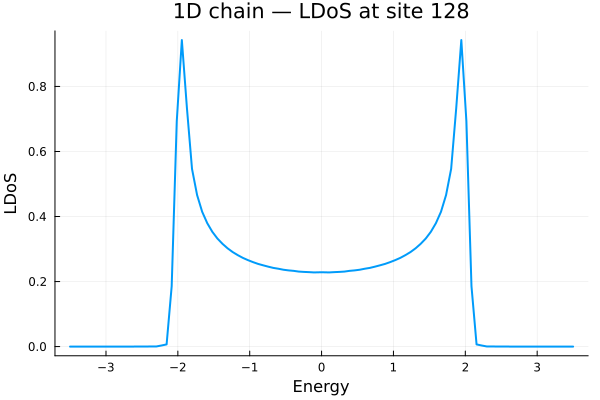

In [4]:
ω_phys = range(-3.5, 3.5; length=100)
ω_resc = ω_phys ./ H1.scale

site_idx  = H1.N ÷ 2
psi_site  = TensorBinding.binary_to_MPS(site_idx, H1.L, H1.sites)
ldos_1d   = Float64[]

for ω in ω_resc
    if abs(ω) >= 1.0
        push!(ldos_1d, 0.0)
        continue
    end
    A_mpo = TensorBinding.get_ldos_w_from_Tn(Tn_list, Ncheb, ω; maxdim=maxdim)
    push!(ldos_1d, real(inner(psi_site, apply(A_mpo, psi_site))))
end

plot(ω_phys, ldos_1d;
     xlabel="Energy", ylabel="LDoS",
     title="1D chain — LDoS at site $(site_idx)",
     legend=false, lw=2)

### 1c. Band structure A(k,ω) via QFT

In the quantics representation the `L` qubit sites encode real-space position in binary.
The QFT maps this to momentum space. The correct spectral function is:

$$A(k,\omega) = \langle k \mid F\,\delta(\omega - H)\,F^\dagger \mid k \rangle$$

The k-states are encoded **LSB-first** to match the `QuanticsTCI` QFT convention.
`get_bands` pre-builds the QFT operators once and loops over ω, reusing `Tn_list`.
The result is a `(N_k × N_ω)` matrix displayed as a heatmap.


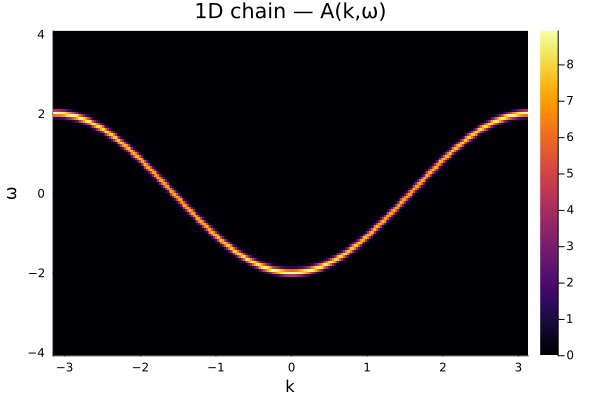

In [5]:
ω_resc_bands = range(-0.9, 0.9; length=120)
ω_phys_bands = ω_resc_bands .* H1.scale

# Conjugate δ(ω−H) by QFT for each ω → A(k,ω) matrix [N_k × N_ω]
Ak_w = TensorBinding.get_bands(Tn_list, Ncheb, H1.sites, ω_resc_bands;
                                tol=1e-9, maxdim=100)

k_axis = (2π / H1.N) .* (0:H1.N-1) .- π   # BZ: [-π, π)

heatmap(k_axis, collect(ω_phys_bands), Ak_w';
        xlabel="k", ylabel="ω",
        title="1D chain — A(k,ω)",
        color=:inferno, clims=(0, maximum(Ak_w)))

---
## 2. Adding second-neighbour hopping with `add_hopping!`

`add_hopping!(H, f)` compresses `f(i,j)` via TCI and adds it to the existing MPO,
automatically invalidating the Chebyshev cache.

$$H = -t_1 \sum_{|i-j|=1} c_i^\dagger c_j - t_2 \sum_{|i-j|=2} c_i^\dagger c_j$$

Exact dispersion: $\varepsilon(k) = -2t_1 \cos k - 2t_2 \cos 2k$,
overlaid as a dashed curve on the A(k,ω) heatmap.


In [8]:
t1 = 1.0
t2 = 0.3

H2 = TensorBinding.get_Hamiltonian("chain_1d", t1; L=L, scale=5.5)
TensorBinding.add_hopping!(H2, (i, j) -> abs(i - j) == 2 ? -t2 : 0.0; type=Float64)
println(H2)

MPS COMPUTED!
Turned into MPO!
TBHamiltonian | L=8, N=256, scale=5.5, maxlinkdim=5 | geometry: 256 sites, 1D | no Tn cache


In [9]:
Ncheb_nnn  = 200
Tn_list_h2 = TensorBinding.KPM_Tn(H2.mpo / H2.scale, Ncheb_nnn, H2.sites; maxdim=maxdim)

9
10
15
15
16
16
16
16
16
16
16
16
16
16
16
16
16
18
18
18
20
20
22
22
22
23
23
24
24
24
24
26
26
26
28
28
29
30
30
30
30
31
32
32
32
32
33
33
34
35
35
37
36
37
38
38
39
39
39
40
40
40
40
41
42
42
43
43
45
45
45
46
46
47
46
48
48
48
47
48
49
48
49
48
49
48
48
48
49
48
49
48
49
50
49
49
49
49
49
49
49
49
49
50
49
50
49
50
49
51
50
51
50
50
51
50
51
51
51
51
51
51
51
51
52
51
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
52
53
52
53
52
53
52
53
52
53
52
53
52
53
52
53
52
53
52
53
52
53
52
53
52
53
52
53
52
53
52
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53


200-element Vector{MPO}:
 MPO
[1] ((dim=2|id=968|"Qubit,Site,n=1")', (dim=2|id=968|"Qubit,Site,n=1"), (dim=1|id=822|"Link,l=1"))
[2] ((dim=2|id=561|"Qubit,Site,n=2")', (dim=2|id=561|"Qubit,Site,n=2"), (dim=1|id=453|"Link,l=2"), (dim=1|id=822|"Link,l=1"))
[3] ((dim=2|id=191|"Qubit,Site,n=3")', (dim=2|id=191|"Qubit,Site,n=3"), (dim=1|id=76|"Link,l=3"), (dim=1|id=453|"Link,l=2"))
[4] ((dim=2|id=511|"Qubit,Site,n=4")', (dim=2|id=511|"Qubit,Site,n=4"), (dim=1|id=159|"Link,l=4"), (dim=1|id=76|"Link,l=3"))
[5] ((dim=2|id=230|"Qubit,Site,n=5")', (dim=2|id=230|"Qubit,Site,n=5"), (dim=1|id=513|"Link,l=5"), (dim=1|id=159|"Link,l=4"))
[6] ((dim=2|id=767|"Qubit,Site,n=6")', (dim=2|id=767|"Qubit,Site,n=6"), (dim=1|id=329|"Link,l=6"), (dim=1|id=513|"Link,l=5"))
[7] ((dim=2|id=456|"Qubit,Site,n=7")', (dim=2|id=456|"Qubit,Site,n=7"), (dim=1|id=123|"Link,l=7"), (dim=1|id=329|"Link,l=6"))
[8] ((dim=2|id=904|"Qubit,Site,n=8")', (dim=2|id=904|"Qubit,Site,n=8"), (dim=1|id=123|"Link,l=7"))

 MPO
[1] ((dim=2|

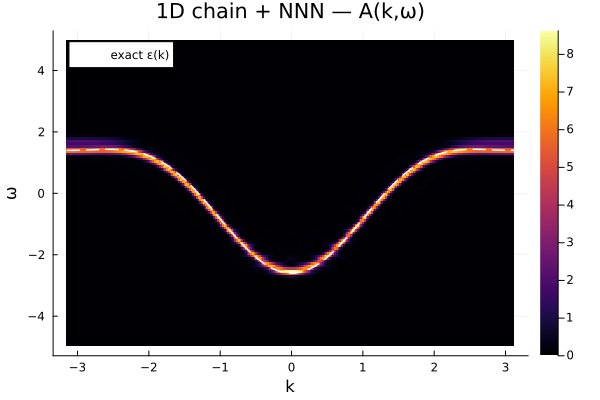

In [10]:
ω_resc_nnn  = range(-0.9, 0.9; length=120)
ω_phys_nnn  = ω_resc_nnn .* H2.scale

Ak_w_nnn = TensorBinding.get_bands(Tn_list_h2, Ncheb_nnn, H2.sites, ω_resc_nnn;
                                    tol=1e-9, maxdim=100)

k_axis_nnn = (2π / H2.N) .* (0:H2.N-1) .- π

p = heatmap(k_axis_nnn, collect(ω_phys_nnn), Ak_w_nnn';
            xlabel="k", ylabel="ω",
            title="1D chain + NNN — A(k,ω)",
            color=:inferno, clims=(0, maximum(Ak_w_nnn)))

# Overlay exact dispersion
ε_exact = -2t1 .* cos.(k_axis_nnn) .- 2t2 .* cos.(2 .* k_axis_nnn)
plot!(p, k_axis_nnn, ε_exact; lw=1.5, ls=:dash, color=:white, label="exact ε(k)")

---
## 2b. Aubry-Andre-Harper (AAH) quasicrystal

The AAH model adds a quasiperiodic on-site potential:

$$H = -t \sum_{\langle i,j \rangle} c_i^\dagger c_j + V \sum_i \cos(2\pi b\,i + \phi)\,n_i,
\qquad b = \frac{1+\sqrt{5}}{2}$$

Exact localisation transition at $V = 2t$:
- $V < 2t$ — all eigenstates **extended** (metallic), smooth LDoS
- $V > 2t$ — all eigenstates **localised** (insulating), spiky LDoS

Built via `get_Hamiltonian("aah", (V=..., phi=..., t=...); L=L)`.


In [ ]:
# --- Delocalised phase: V < 2t ---
t_aah = 1.0
H_del = TensorBinding.get_Hamiltonian("aah", (V=1.0, phi=0.0, t=t_aah); L=L, scale=4.5)
println(H_del)

# --- Localised phase: V > 2t ---
H_loc = TensorBinding.get_Hamiltonian("aah", (V=3.0, phi=0.0, t=t_aah); L=L, scale=6.5)
println(H_loc)

In [ ]:
Ncheb_aah = 200

Tn_del = TensorBinding.KPM_Tn(H_del.mpo / H_del.scale, Ncheb_aah, H_del.sites; maxdim=maxdim)
Tn_loc = TensorBinding.KPM_Tn(H_loc.mpo / H_loc.scale, Ncheb_aah, H_loc.sites; maxdim=maxdim)

site_c   = H_del.N ÷ 2
psi_c_del = TensorBinding.binary_to_MPS(site_c, H_del.L, H_del.sites)
psi_c_loc = TensorBinding.binary_to_MPS(site_c, H_loc.L, H_loc.sites)

ω_aah_phys = range(-4.0, 4.0; length=120)

ldos_del = Float64[]
ldos_loc = Float64[]
for ω_p in ω_aah_phys
    ω_d = ω_p / H_del.scale
    ω_l = ω_p / H_loc.scale
    if abs(ω_d) < 1.0
        A = TensorBinding.get_ldos_w_from_Tn(Tn_del, Ncheb_aah, ω_d; maxdim=maxdim)
        push!(ldos_del, real(inner(psi_c_del, apply(A, psi_c_del))))
    else
        push!(ldos_del, 0.0)
    end
    if abs(ω_l) < 1.0
        A = TensorBinding.get_ldos_w_from_Tn(Tn_loc, Ncheb_aah, ω_l; maxdim=maxdim)
        push!(ldos_loc, real(inner(psi_c_loc, apply(A, psi_c_loc))))
    else
        push!(ldos_loc, 0.0)
    end
end

pa = plot(ω_aah_phys, ldos_del; label="V=1 (delocalised)", lw=2,
          xlabel="Energy", ylabel="LDoS", title="AAH — LDoS at central site")
plot!(pa, ω_aah_phys, ldos_loc; label="V=3 (localised)", lw=2, ls=:dash)

---
## 2c. Custom MPO — spatially modulated hopping

Pass any function `f(i, j)` to `get_Hamiltonian("custom", f; L, scale)` and TCI
compresses the full `N x N` hopping matrix into an MPO automatically.

Here we use a sinusoidally modulated nearest-neighbour chain:

$$t_{i,i\pm1} = 1 + \delta\cos\!\left(\frac{2\pi i}{\lambda}\right),
\quad \delta = 0.5,\quad \lambda = N/4$$

The spatial modulation breaks translational symmetry; the LDoS at different
sites reveals site-dependent spectral weight redistribution.


In [ ]:
δ_mod  = 0.5
λ_mod  = H1.N / 4

# f(i,j): 1-based site indices, NN hopping with a cosine envelope
f_mod(i, j) = abs(i - j) == 1 ?
    -(1.0 + δ_mod * cos(2π * (i + j - 1) / 2 / λ_mod)) : 0.0

H_cust = TensorBinding.get_Hamiltonian("custom", f_mod;
             L=L, scale=5.0, type=Float64)
println(H_cust)

In [ ]:
Ncheb_cust = 200
Tn_cust    = TensorBinding.KPM_Tn(H_cust.mpo / H_cust.scale, Ncheb_cust,
                                   H_cust.sites; maxdim=maxdim)

# DoS = sum of LDoS over all sites — sample a few evenly spaced sites
ω_cust_phys = range(-4.0, 4.0; length=120)
sample_sites = [H_cust.N ÷ 8, H_cust.N ÷ 4, H_cust.N ÷ 2]

ldos_cust = [Float64[] for _ in sample_sites]
psi_cust  = [TensorBinding.binary_to_MPS(s, H_cust.L, H_cust.sites) for s in sample_sites]

for ω_p in ω_cust_phys
    ω_r = ω_p / H_cust.scale
    for (k, psi) in enumerate(psi_cust)
        if abs(ω_r) < 1.0
            A = TensorBinding.get_ldos_w_from_Tn(Tn_cust, Ncheb_cust, ω_r; maxdim=maxdim)
            push!(ldos_cust[k], real(inner(psi, apply(A, psi))))
        else
            push!(ldos_cust[k], 0.0)
        end
    end
end

pc = plot(ω_cust_phys, ldos_cust[1]; label="site $(sample_sites[1])", lw=2,
          xlabel="Energy", ylabel="LDoS",
          title="Custom modulated chain — LDoS at selected sites")
for k in 2:length(sample_sites)
    plot!(pc, ω_cust_phys, ldos_cust[k]; label="site $(sample_sites[k])", lw=2)
end
pc

---
## 3. 2D square lattice — density matrix via purification

`L = 8` qubits, `Lx = Ly = 4`, `N = 256` sites. 2D NN bandwidth `≈ 8|t|`, `scale = 9`.

Purification iterates a polynomial map on ρ to drive eigenvalues toward exactly 0 or 1,
approximating $\theta(\mu - H)$ without a Chebyshev expansion.

**Workflow:**
1. `purification_initial_guess`: $\rho_0 = (I - H/\mathrm{scale})/2$, spectrum mapped to $[0,1]$
2. **McWeeny**: $\rho_{n+1} = 3\rho_n^2 - 2\rho_n^3$, quadratic convergence, 2 MPO products/step
3. **SP2**: $\rho_{n+1} = \rho_n^2$ or $2\rho_n - \rho_n^2$ based on $\mathrm{Tr}(\rho^2)$ vs $N_{\mathrm{el}}$, 1 product/step


In [11]:
Lsq = 8
Lx  = 16
H3  = TensorBinding.get_Hamiltonian("square_2d", 1.0; L=Lsq, Lx=Lx, scale=9.0)
println(H3)

TBHamiltonian | L=8, N=256, scale=9.0, maxlinkdim=5 | geometry: 256 sites, 2D | no Tn cache


In [14]:
ρ0 = TensorBinding.purification_initial_guess(H3.mpo, H3.scale, H3.sites; maxdim=100, cutoff=1e-8)
println("Tr(ρ₀) = ", real(tr(ρ0)), "  (expected ≈ N/2 = ", H3.N ÷ 2, ")")

Tr(ρ₀) = 127.99999999999997  (expected ≈ N/2 = 128)


In [16]:
ρ_mc = TensorBinding.mcweeny_purify(ρ0; maxiters=25, maxdim=200, cutoff=1e-8, tol=1e-5, verbose=true)
println("McWeeny → Tr(ρ) = ", real(tr(ρ_mc)),
        "  maxlinkdim = ", ITensorMPS.maxlinkdim(ρ_mc))

McWeeny iter 1: ‖ρ²-ρ‖/‖ρ‖ = 0.4669442192293404, maxlinkdim = 5
McWeeny iter 2: ‖ρ²-ρ‖/‖ρ‖ = 0.4341195882390856, maxlinkdim = 12
McWeeny iter 3: ‖ρ²-ρ‖/‖ρ‖ = 0.3825714195548539, maxlinkdim = 17
McWeeny iter 4: ‖ρ²-ρ‖/‖ρ‖ = 0.32069555027924845, maxlinkdim = 20
McWeeny iter 5: ‖ρ²-ρ‖/‖ρ‖ = 0.2636482383300577, maxlinkdim = 26
McWeeny iter 6: ‖ρ²-ρ‖/‖ρ‖ = 0.217145633937761, maxlinkdim = 35
McWeeny iter 7: ‖ρ²-ρ‖/‖ρ‖ = 0.1796848284846231, maxlinkdim = 45
McWeeny iter 8: ‖ρ²-ρ‖/‖ρ‖ = 0.14917907805434197, maxlinkdim = 62
McWeeny iter 9: ‖ρ²-ρ‖/‖ρ‖ = 0.12434152398039536, maxlinkdim = 116
McWeeny iter 10: ‖ρ²-ρ‖/‖ρ‖ = 0.10581625365395168, maxlinkdim = 157
McWeeny iter 11: ‖ρ²-ρ‖/‖ρ‖ = 0.09391444086868815, maxlinkdim = 185
McWeeny iter 12: ‖ρ²-ρ‖/‖ρ‖ = 0.0872153406556808, maxlinkdim = 199
McWeeny iter 13: ‖ρ²-ρ‖/‖ρ‖ = 0.0841408270539549, maxlinkdim = 200
McWeeny iter 14: ‖ρ²-ρ‖/‖ρ‖ = 0.08303178747225115, maxlinkdim = 200
McWeeny iter 15: ‖ρ²-ρ‖/‖ρ‖ = 0.08202638634949845, maxlinkdim = 200
McWeeny

In [18]:
Nel   = H3.N ÷ 2
ρ_sp2 = TensorBinding.sp2_purify(ρ0, Nel; maxiters=25, maxdim=200, cutoff=1e-8, tol=1e-5, verbose=true)
println("SP2    → Tr(ρ) = ", real(tr(ρ_sp2)),
        "  maxlinkdim = ", ITensorMPS.maxlinkdim(ρ_sp2))

SP2 iter 1: ‖ρ²-ρ‖/‖ρ‖ = 0.4669442192293404, maxlinkdim = 5
SP2 iter 2: ‖ρ²-ρ‖/‖ρ‖ = 0.2516846200109349, maxlinkdim = 12
SP2 iter 3: ‖ρ²-ρ‖/‖ρ‖ = 0.3882264512938582, maxlinkdim = 14
SP2 iter 4: ‖ρ²-ρ‖/‖ρ‖ = 0.2097970783910696, maxlinkdim = 14
SP2 iter 5: ‖ρ²-ρ‖/‖ρ‖ = 0.2990739764830302, maxlinkdim = 15
SP2 iter 6: ‖ρ²-ρ‖/‖ρ‖ = 0.1718194334226542, maxlinkdim = 18
SP2 iter 7: ‖ρ²-ρ‖/‖ρ‖ = 0.21918122547711394, maxlinkdim = 20
SP2 iter 8: ‖ρ²-ρ‖/‖ρ‖ = 0.2638026404494445, maxlinkdim = 24
SP2 iter 9: ‖ρ²-ρ‖/‖ρ‖ = 0.1774800435346332, maxlinkdim = 26
SP2 iter 10: ‖ρ²-ρ‖/‖ρ‖ = 0.19995895590934948, maxlinkdim = 32
SP2 iter 11: ‖ρ²-ρ‖/‖ρ‖ = 0.1414362403858294, maxlinkdim = 35
SP2 iter 12: ‖ρ²-ρ‖/‖ρ‖ = 0.15004290196345837, maxlinkdim = 43
SP2 iter 13: ‖ρ²-ρ‖/‖ρ‖ = 0.1615061422568114, maxlinkdim = 49
SP2 iter 14: ‖ρ²-ρ‖/‖ρ‖ = 0.12042988742221916, maxlinkdim = 49
SP2 iter 15: ‖ρ²-ρ‖/‖ρ‖ = 0.12400860485927886, maxlinkdim = 82
SP2 iter 16: ‖ρ²-ρ‖/‖ρ‖ = 0.1290219153644256, maxlinkdim = 107
SP2 iter 17:

### Compare to KPM and check idempotency

A perfect projector satisfies $\rho^2 = \rho$, so $\|\rho^2 - \rho\|/\|\rho\| = 0$.
KPM at finite `Ncheb` leaves Gibbs ringing in the eigenvalue spectrum;
purification iterates this away to yield a sharper projector at lower bond dimension.


In [19]:
Tn_sq  = TensorBinding.KPM_Tn(H3.mpo / H3.scale, 80, H3.sites; maxdim=100)
ρ_kpm3 = TensorBinding.get_density_from_Tn(Tn_sq, 80; fermi=0.0, maxdim=100)
println("KPM    → Tr(ρ) = ", real(tr(ρ_kpm3)),
        "  maxlinkdim = ", ITensorMPS.maxlinkdim(ρ_kpm3))

function idempotency_residual(ρ)
    ρ2 = apply(ρ, ρ; cutoff=1e-10)
    return norm(+(ρ2, -1.0 * ρ; cutoff=1e-12)) / norm(ρ)
end

println()
println("Idempotency residual ‖ρ²−ρ‖/‖ρ‖ (0 = perfect projector):")
println("  McWeeny : ", idempotency_residual(ρ_mc))
println("  SP2     : ", idempotency_residual(ρ_sp2))
println("  KPM     : ", idempotency_residual(ρ_kpm3))

13
20
22
20
26
27
28
32
32
34
37
37
39
41
41
43
44
45
47
47
48
49
49
50
51
52
52
52
53
54
54
54
55
55
56
56
57
57
58
60
61
62
63
64
65
66
68
69
71
72
73
75
77
79
81
83
84
85
87
89
90
91
92
93
94
94
95
95
96
97
98
98
99
99
99
99
100
100
KPM    → Tr(ρ) = 127.99993076689861  maxlinkdim = 45

Idempotency residual ‖ρ²−ρ‖/‖ρ‖ (0 = perfect projector):
  McWeeny : 0.06519321079838732
  SP2     : 0.0614293202703382
  KPM     : 0.1355388826419442


---
## 4. 2D square lattice — LDoS at the sample centre

Same approach as section 1b applied to the 2D Hamiltonian `H3`.
The 2D square lattice DoS has a logarithmic van Hove singularity at $\omega = 0$
(saddle point at the M-point of the Brillouin zone), clearly visible in the LDoS
at a bulk site.


13
20
22
20
26
27
28
32
32
34
37
37
39
41
41
43
44
45
47
47
48
49
49
50
51
52
52
52
53
54
54
54
55
55
56
56
57
57
58
60
61
62
63
64
65
66
68
69
71
72
73
75
77
79
81
83
84
85
87
89
90
91
92
93
94
94
95
95
96
97
98
98
99
99
99
99
100
100


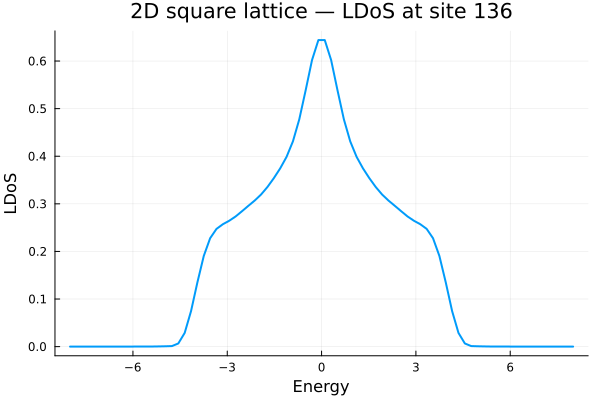

In [26]:
Ncheb_2d = 80
Tn_sq2   = TensorBinding.KPM_Tn(H3.mpo / H3.scale, Ncheb_2d, H3.sites; maxdim=100)

ω_phys_2d = range(-8.0, 8.0; length=80)
ω_resc_2d = ω_phys_2d ./ H3.scale

Ly = Lx

center     = (Lx ÷ 2) + (Ly ÷ 2) * Lx    # Center site index in row-major order
psi_center = TensorBinding.binary_to_MPS(center, H3.L, H3.sites)
ldos_2d    = Float64[]

for ω in ω_resc_2d
    if abs(ω) >= 1.0
        push!(ldos_2d, 0.0)
        continue
    end
    A_mpo = TensorBinding.get_ldos_w_from_Tn(Tn_sq2, Ncheb_2d, ω; maxdim=200)
    push!(ldos_2d, real(inner(psi_center, apply(A_mpo, psi_center))))
end

plot(ω_phys_2d, ldos_2d;
     xlabel="Energy", ylabel="LDoS",
     title="2D square lattice — LDoS at site $(center)",
     legend=false, lw=2)

---
## 5. Real-time evolution via TDVP

TDVP (Time-Dependent Variational Principle) integrates the Schrodinger equation
directly on the MPS manifold, keeping the bond dimension bounded at each step.

We use `evolve_with_tdvp` from `TensorBinding.Timeev_tk` on a small 1D chain
(`L=4`, `N=16`), starting from a superposition of the two central basis states.
`compute_basis_overlaps` tracks the full probability distribution over the trajectory.


### 5a. Hamiltonian and initial state

`L=4` gives `N=16` sites — small enough to track every computational-basis overlap
explicitly. The initial state is an equal superposition of the two central sites.


In [51]:
# Small system so the MPO propagator TCI is fast
L_t  = 8
N_t  = 2^L_t

H_t     = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L_t, scale=4.5)
sites_t = H_t.sites

# Initial state: equal superposition of the two central basis states
sitemid = N_t ÷ 2
psi0_t  = (
    TensorBinding.binary_to_MPS(sitemid,     L_t, sites_t) +
    TensorBinding.binary_to_MPS(sitemid - 1, L_t, sites_t)
) / sqrt(2)

println(H_t)
println("psi0 norm = ", real(inner(psi0_t, psi0_t)))

TBHamiltonian | L=8, N=256, scale=4.5, maxlinkdim=3 | geometry: 256 sites, 1D | no Tn cache
psi0 norm = 0.9999999999999998


### 5b. TDVP evolution and visualisation

`evolve_with_tdvp` returns the MPS at every time step.
`compute_basis_overlaps` evaluates `<x|psi(t)>` for all basis states,
returning the probability distribution as a function of site and step.
The heatmaps show quantum spreading and interference structure.


In [56]:
dt_t    = 0.01
nsteps_t = 500

tdvp_states = TensorBinding.evolve_with_tdvp(
    -1im * H_t.mpo, psi0_t, nsteps_t, dt_t;
    normalize_each_step = true,
    maxdim  = 200,
    cutoff  = 1e-10,
    nsite   = 2,
)

501-element Vector{MPS}:
 MPS
[1] ((dim=2|id=35|"Qubit,Site,n=1"), (dim=2|id=889|"Link,l=1"))
[2] ((dim=2|id=241|"Qubit,Site,n=2"), (dim=2|id=970|"Link,l=2"), (dim=2|id=889|"Link,l=1"))
[3] ((dim=2|id=812|"Qubit,Site,n=3"), (dim=2|id=727|"Link,l=3"), (dim=2|id=970|"Link,l=2"))
[4] ((dim=2|id=687|"Qubit,Site,n=4"), (dim=2|id=861|"Link,l=4"), (dim=2|id=727|"Link,l=3"))
[5] ((dim=2|id=392|"Qubit,Site,n=5"), (dim=2|id=866|"Link,l=5"), (dim=2|id=861|"Link,l=4"))
[6] ((dim=2|id=309|"Qubit,Site,n=6"), (dim=2|id=190|"Link,l=6"), (dim=2|id=866|"Link,l=5"))
[7] ((dim=2|id=789|"Qubit,Site,n=7"), (dim=2|id=513|"Link,l=7"), (dim=2|id=190|"Link,l=6"))
[8] ((dim=2|id=878|"Qubit,Site,n=8"), (dim=2|id=513|"Link,l=7"))

 MPS
[1] ((dim=2|id=767|"Link,l=1"), (dim=2|id=35|"Qubit,Site,n=1"))
[2] ((dim=2|id=207|"Link,l=2"), (dim=2|id=241|"Qubit,Site,n=2"), (dim=2|id=767|"Link,l=1"))
[3] ((dim=2|id=835|"Link,l=3"), (dim=2|id=812|"Qubit,Site,n=3"), (dim=2|id=207|"Link,l=2"))
[4] ((dim=2|id=301|"Link,l=4"), (di

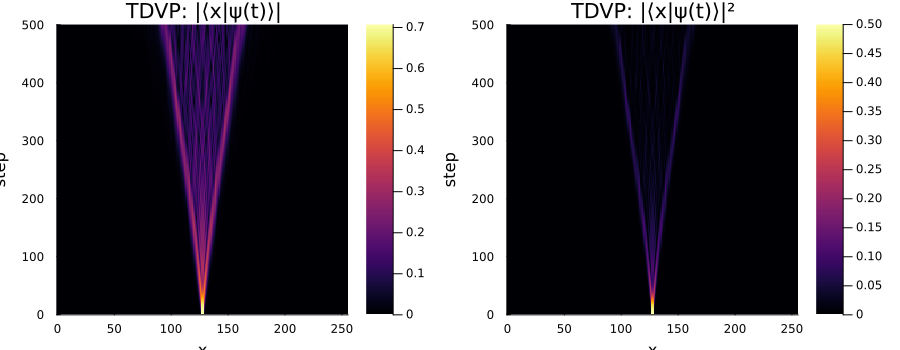

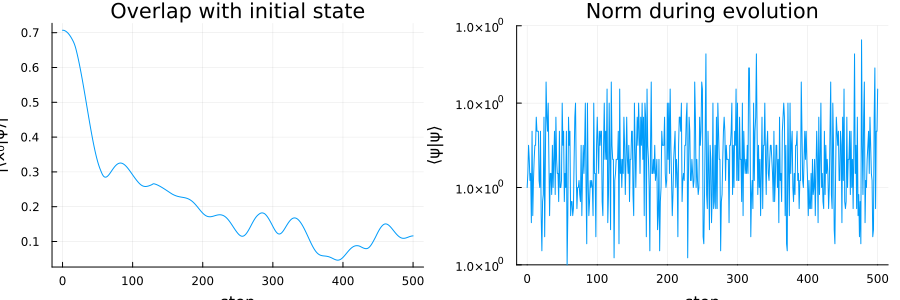

In [57]:
tdvp_data  = TensorBinding.compute_basis_overlaps(tdvp_states, L_t, sites_t)
steps_axis = 0:nsteps_t
basis_axis = 0:(N_t - 1)

p1 = heatmap(basis_axis, steps_axis, tdvp_data.abs_overlaps;
    xlabel="x", ylabel="step", title="TDVP: |⟨x|ψ(t)⟩|", color=:inferno)
p2 = heatmap(basis_axis, steps_axis, tdvp_data.probabilities;
    xlabel="x", ylabel="step", title="TDVP: |⟨x|ψ(t)⟩|²", color=:inferno)
p3 = plot(steps_axis, tdvp_data.abs_overlaps[:, sitemid];
    xlabel="step", ylabel="|⟨x₀|ψ⟩|", title="Overlap with initial state", legend=false)
p4 = plot(steps_axis, tdvp_data.norms;
    xlabel="step", ylabel="⟨ψ|ψ⟩", title="Norm during evolution", legend=false)

display(plot(p1, p2; layout=(1,2), size=(900,350)))
display(plot(p3, p4; layout=(1,2), size=(900,300)))